In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='darkgrid')

print("All libraries loaded successfully")

All libraries loaded successfully


In [3]:
# Connect to your SQLite database
conn = sqlite3.connect('/Users/Anu/Documents/olist_project/olist_db.db')

# Load the churn flags view into a dataframe
df = pd.read_sql_query("SELECT * FROM vw_churn_flags", conn)

print(f"Total customers: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSample data:")
df.head()

Total customers: 93470

Columns: ['customer_unique_id', 'customer_city', 'customer_state', 'total_orders', 'total_revenue', 'avg_order_value', 'first_order_date', 'last_order_date', 'recency_days', 'recency_score', 'frequency_score', 'monetary_score', 'rfm_total_score', 'customer_segment', 'is_churned', 'is_at_risk']

Sample data:


,customer_unique_id,customer_city,customer_state,total_orders,total_revenue,avg_order_value,first_order_date,last_order_date,recency_days,recency_score,frequency_score,monetary_score,rfm_total_score,customer_segment,is_churned,is_at_risk
0,21dbe8eabd00b34492a939c540e2b1a7,sao paulo,SP,1,14.29,14.29,2018-08-29,2018-08-29,0,5,1,1,7,New Customer,0,0
1,b701bebbdf478f5500348f03aff62121,sao caetano do sul,SP,1,33.23,33.23,2018-08-29,2018-08-29,0,5,1,1,7,New Customer,0,0
2,7febafa06d9d8f232a900a2937f04338,paracatu,MG,1,61.29,61.29,2018-08-29,2018-08-29,0,5,2,2,9,New Customer,0,0
3,7a22d14aa3c3599238509ddca4b93b01,sao paulo,SP,1,73.10,73.10,2018-08-29,2018-08-29,0,5,2,2,9,New Customer,0,0
4,f80013faf776e37bcea7634d59c2181e,sao paulo,SP,1,74.21,74.21,2018-08-29,2018-08-29,0,5,2,2,9,New Customer,0,0


In [4]:
# Segment distribution
segment_summary = df.groupby('customer_segment').agg(
    customer_count=('customer_unique_id', 'count'),
    total_revenue=('total_revenue', 'sum'),
    avg_revenue=('total_revenue', 'mean'),
    churned=('is_churned', 'sum'),
    at_risk=('is_at_risk', 'sum')
).round(2).reset_index()

segment_summary['churn_rate'] = (segment_summary['churned'] / segment_summary['customer_count'] * 100).round(2)
segment_summary = segment_summary.sort_values('total_revenue', ascending=False)

print(segment_summary)

     customer_segment  customer_count  total_revenue  avg_revenue  churned  \
0             At Risk           22024     5329163.34       241.97    22024   
2            Champion           15116     4673512.03       309.18        0   
4               Loyal           18942     3357405.41       177.25    10577   
6        New Customer           14472      793163.41        54.81        0   
3                Lost            7797      431974.91        55.40     7797   
5     Needs Attention            7534      423160.14        56.17     7534   
7  Potential Loyalist            7552      411195.22        54.45     7263   
1      Cant Lose Them              33        2887.31        87.49       33   

   at_risk  churn_rate  
0        0      100.00  
2     7636        0.00  
4     4537       55.84  
6     7256        0.00  
3        0      100.00  
5        0      100.00  
7      289       96.17  
1        0      100.00  


/var/folders/85/r8gb70qx3cg0rfv3mwj5j3y80000gn/T/ipykernel_9735/4291155315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


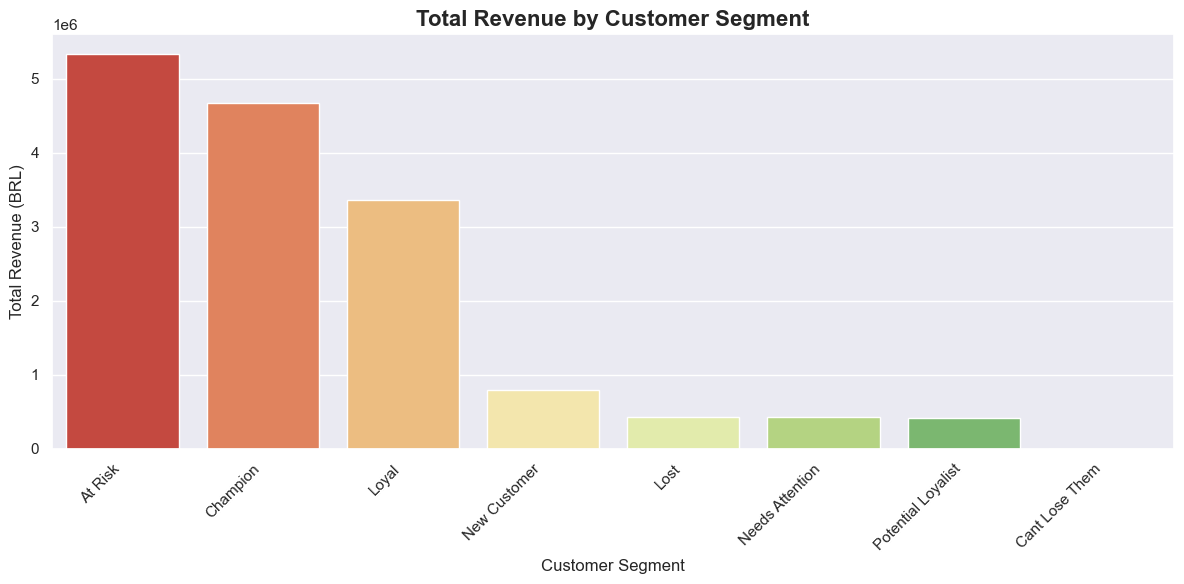

Chart saved successfully


In [5]:
# Chart 1: Revenue by Segment
plt.figure(figsize=(12, 6))
sns.barplot(
    data=segment_summary,
    x='customer_segment',
    y='total_revenue',
    palette='RdYlGn'
)
plt.title('Total Revenue by Customer Segment', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/Users/Anu/Documents/olist_project/chart1_revenue_by_segment.png', dpi=150)
plt.show()
print("Chart saved successfully")

/var/folders/85/r8gb70qx3cg0rfv3mwj5j3y80000gn/T/ipykernel_9735/3097091412.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


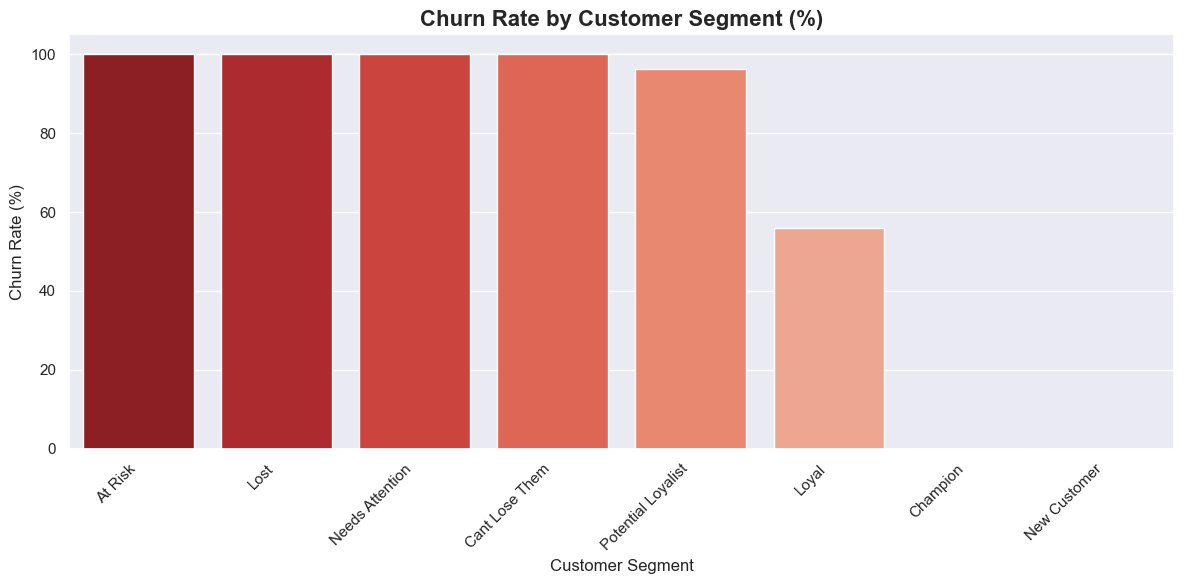

Chart saved successfully


In [6]:
# Chart 2: Churn Rate by Segment
plt.figure(figsize=(12, 6))
sns.barplot(
    data=segment_summary.sort_values('churn_rate', ascending=False),
    x='customer_segment',
    y='churn_rate',
    palette='Reds_r'
)
plt.title('Churn Rate by Customer Segment (%)', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/Users/Anu/Documents/olist_project/chart2_churn_rate_by_segment.png', dpi=150)
plt.show()
print("Chart saved successfully")

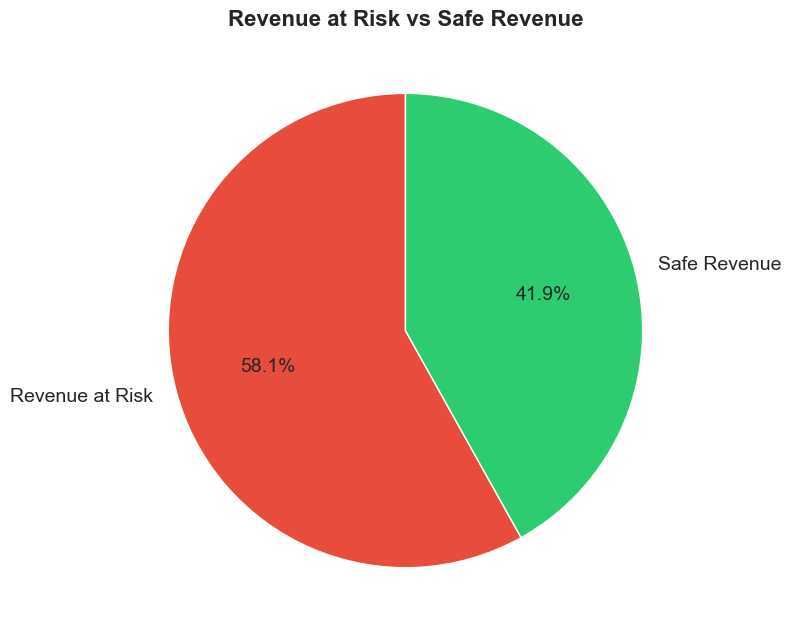

Chart saved successfully


In [7]:
# Chart 3: Revenue at Risk vs Safe Revenue
revenue_status = pd.DataFrame({
    'Status': ['Revenue at Risk', 'Safe Revenue'],
    'Amount': [
        df[df['is_churned'] == 1]['total_revenue'].sum(),
        df[df['is_churned'] == 0]['total_revenue'].sum()
    ]
})

plt.figure(figsize=(8, 8))
plt.pie(
    revenue_status['Amount'],
    labels=revenue_status['Status'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90,
    textprops={'fontsize': 14}
)
plt.title('Revenue at Risk vs Safe Revenue', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/Anu/Documents/olist_project/chart3_revenue_at_risk.png', dpi=150)
plt.show()
print("Chart saved successfully")

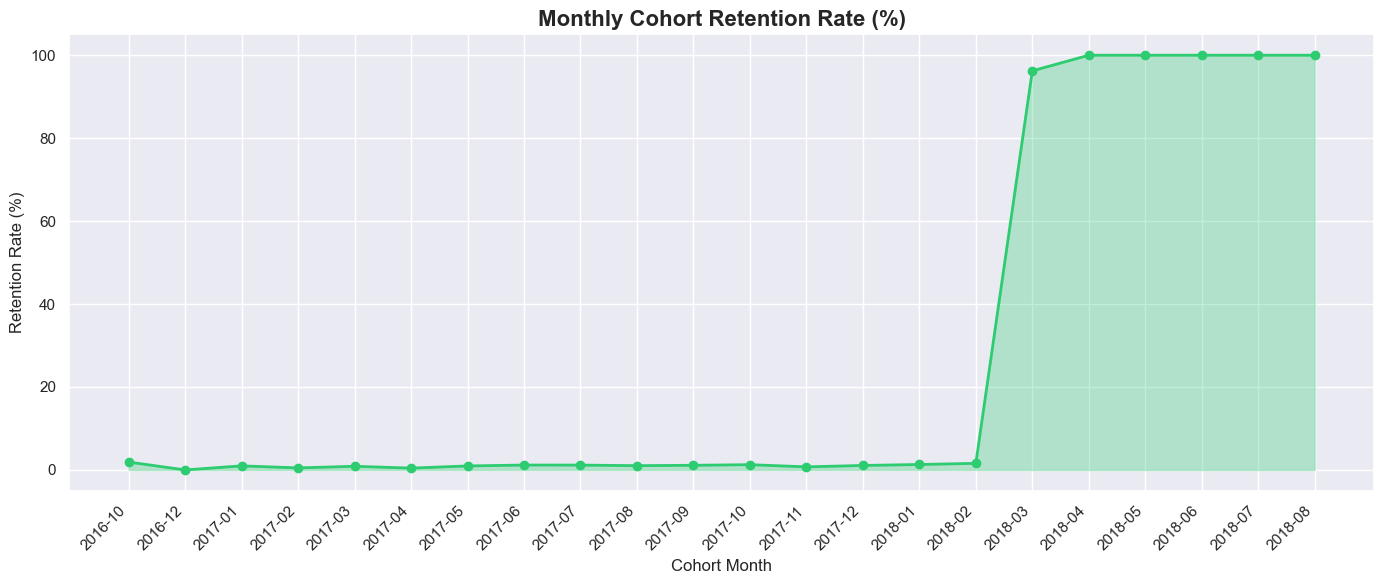

Chart saved successfully


In [8]:
# Chart 4: Monthly Cohort Retention
df['first_order_date'] = pd.to_datetime(df['first_order_date'])
df['last_order_date'] = pd.to_datetime(df['last_order_date'])
df['cohort_month'] = df['first_order_date'].dt.to_period('M')

cohort = df.groupby('cohort_month').agg(
    total_customers=('customer_unique_id', 'count'),
    retained=('is_churned', lambda x: (x == 0).sum())
).reset_index()

cohort['retention_rate'] = (cohort['retained'] / cohort['total_customers'] * 100).round(2)
cohort['cohort_month'] = cohort['cohort_month'].astype(str)

plt.figure(figsize=(14, 6))
plt.plot(cohort['cohort_month'], cohort['retention_rate'], marker='o', color='#2ecc71', linewidth=2)
plt.fill_between(cohort['cohort_month'], cohort['retention_rate'], alpha=0.3, color='#2ecc71')
plt.title('Monthly Cohort Retention Rate (%)', fontsize=16, fontweight='bold')
plt.xlabel('Cohort Month')
plt.ylabel('Retention Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/Users/Anu/Documents/olist_project/chart4_cohort_retention.png', dpi=150)
plt.show()
print("Chart saved successfully")